# 9. Interpretabilidad del modelo final

  INTERPRETABILIDAD — SHAP (modelo final: rf_bin)
SHAP calculado sobre 1,566 municipios-año de test y 36 variables.

Top 15 variables por importancia SHAP (|valor| medio):
                      feature  shap_abs_medio
               media_movil_2a        0.069037
                    tasa_lag1        0.058073
                    tasa_lag2        0.042524
                     longitud        0.030421
         bajo_logro_educativo        0.014979
                    tendencia        0.012742
                      latitud        0.009473
                  dist_bogota        0.009423
             tasa_dependencia        0.005677
             trabajo_infantil        0.005521
 inter_tasa_dependencia_rural        0.005435
 inter_primera_infancia_rural        0.005115
      sin_aseguramiento_salud        0.004669
    barreras_primera_infancia        0.004582
inter_sin_agua_mejorada_rural        0.004213


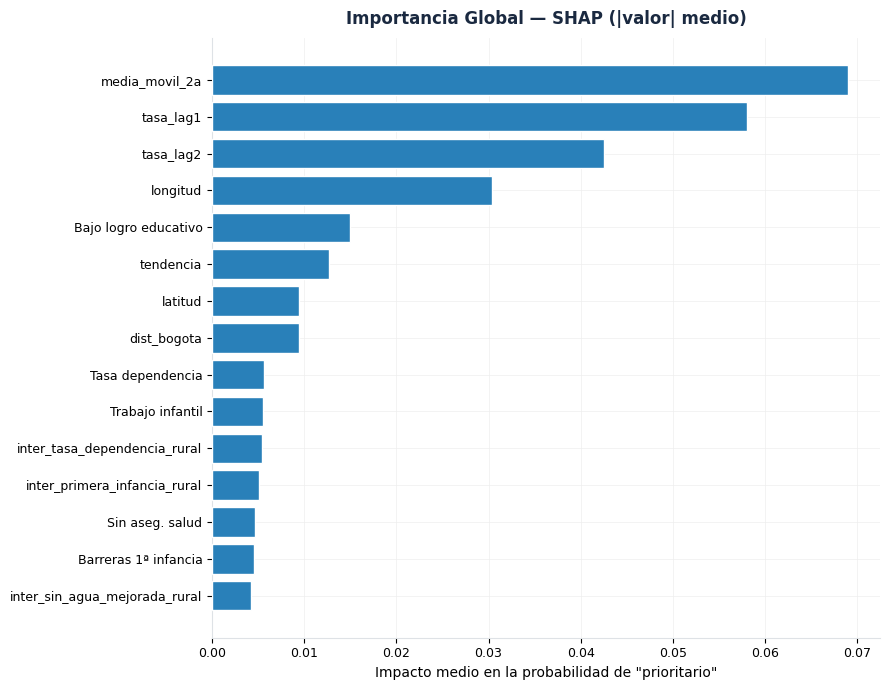

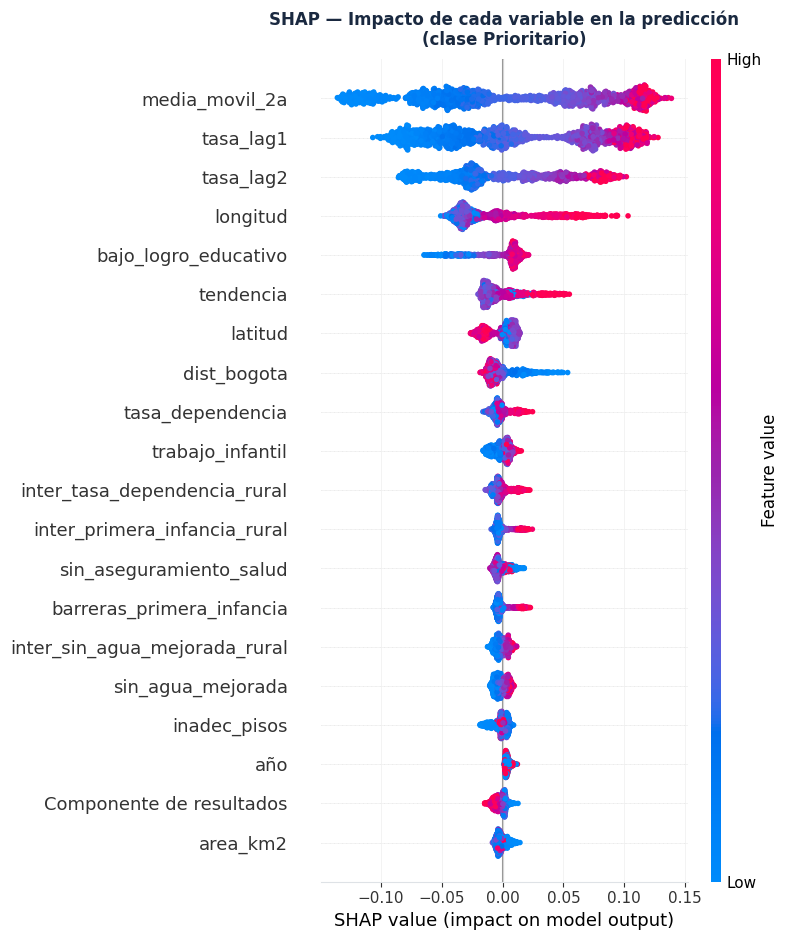

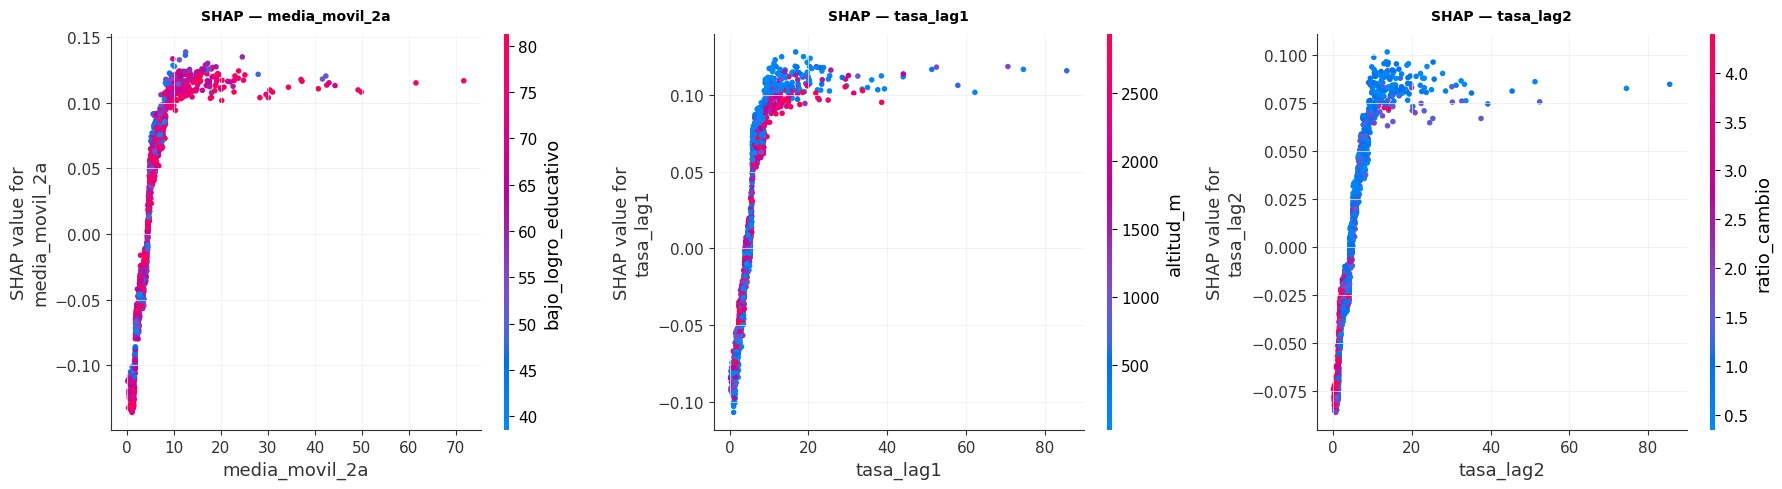


Municipio de mayor riesgo predicho (cod_mun=05002, prob_prioritario=1.000):


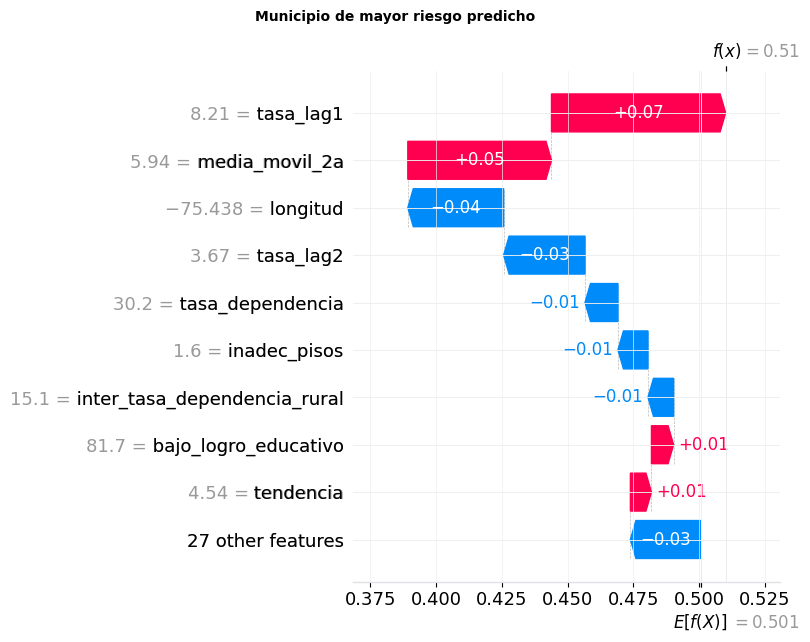


Municipio de menor riesgo predicho (cod_mun=05001, prob_prioritario=0.000):


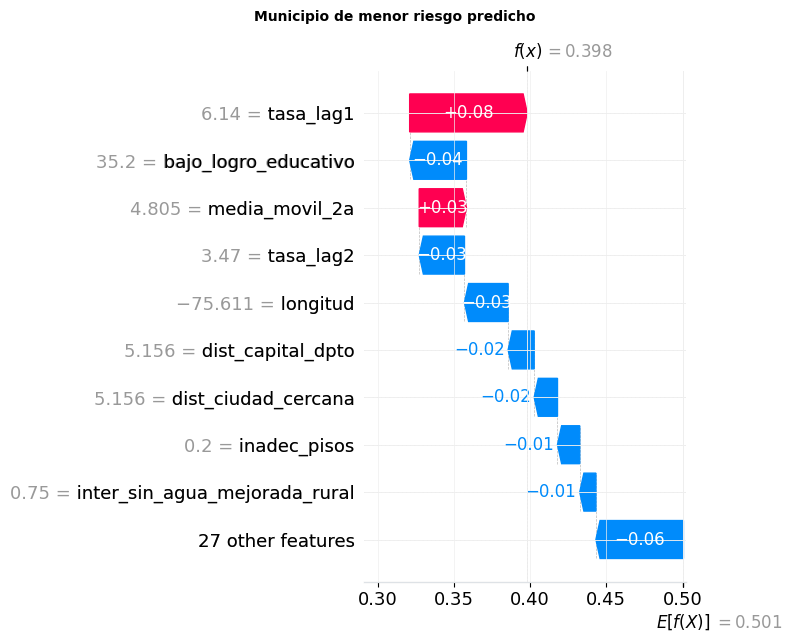


✓ Importancia global SHAP guardada en /content/drive/MyDrive/Máster Data Science/TFM/Modelos/shap_importancia_global.pkl


In [74]:
print("=" * 65)
print("  INTERPRETABILIDAD — SHAP (modelo final: rf_bin)")
print("=" * 65)

# 1. Explainer exacto para modelos de árboles
explainer_rf   = shap.TreeExplainer(rf_bin)
shap_values_rf = explainer_rf(X_te)

if shap_values_rf.values.ndim == 3:
    shap_values_rf = shap_values_rf[:, :, 1]

print(f"SHAP calculado sobre {X_te.shape[0]:,} municipios-año de test "
      f"y {X_te.shape[1]} variables.")

"""**1. Importancia global**"""

importancia_shap = (
    pd.DataFrame({
        'feature':        X_te.columns,
        'shap_abs_medio': np.abs(shap_values_rf.values).mean(axis=0)
    })
    .sort_values('shap_abs_medio', ascending=False)
    .reset_index(drop=True)
)
print("\nTop 15 variables por importancia SHAP (|valor| medio):")
print(importancia_shap.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 7))
top15 = importancia_shap.head(15).iloc[::-1]
ax.barh(top15['feature'].map(lambda f: ETIQ.get(f, f)), top15['shap_abs_medio'],
        color=C['accent'], edgecolor='white', zorder=3)
ax.set_title('Importancia Global — SHAP (|valor| medio)',
             fontweight='bold', color=C['primary'])
ax.set_xlabel('Impacto medio en la probabilidad de "prioritario"')
plt.tight_layout()
plt.savefig(RUTA_IMAGENES / 'shap_01_importancia_global.png', dpi=150, bbox_inches='tight')
plt.show()

"""**2. Beeswarm — dirección y magnitud del impacto**"""

# Sub-muestra solo para que el gráfico no quede saturado; la importancia
# de arriba y los dependence plots de abajo sí usan el test set completo.
MAX_PUNTOS_PLOT = 1500
if X_te.shape[0] > MAX_PUNTOS_PLOT:
    idx_plot = np.random.RandomState(42).choice(X_te.shape[0], MAX_PUNTOS_PLOT, replace=False)
else:
    idx_plot = np.arange(X_te.shape[0])

shap.summary_plot(shap_values_rf.values[idx_plot], X_te.iloc[idx_plot], show=False)
plt.title('SHAP — Impacto de cada variable en la predicción\n(clase Prioritario)',
          fontsize=12, fontweight='bold', color=C['primary'])
plt.tight_layout()
plt.savefig(RUTA_IMAGENES / 'shap_02_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

"""**3. Dependence plots — top 3 variables**"""

top3_vars = importancia_shap['feature'].head(3).tolist()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, var in zip(axes, top3_vars):
    shap.dependence_plot(var, shap_values_rf.values, X_te, ax=ax, show=False)
    ax.set_title(f'SHAP — {ETIQ.get(var, var)}', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(RUTA_IMAGENES / 'shap_03_dependence_top3.png', dpi=150, bbox_inches='tight')
plt.show()

"""**4. Explicación local — casos individuales**"""

idx_prioritario    = int(np.argmax(y_pred_rf))   # municipio-año con mayor prob. predicha
idx_no_prioritario = int(np.argmin(y_pred_rf))   # municipio-año con menor prob. predicha

for nombre_caso, idx in [('Municipio de mayor riesgo predicho', idx_prioritario),
                          ('Municipio de menor riesgo predicho', idx_no_prioritario)]:
    cod = test.iloc[idx]['cod_mun']
    print(f"\n{nombre_caso} (cod_mun={cod}, prob_prioritario={y_pred_rf[idx]:.3f}):")
    shap.plots.waterfall(shap_values_rf[idx], show=False)
    plt.gcf().suptitle(nombre_caso, fontsize=10, fontweight='bold')
    plt.tight_layout()
    sufijo = 'alto' if idx == idx_prioritario else 'bajo'
    plt.savefig(RUTA_IMAGENES / f'shap_04_waterfall_{sufijo}.png', dpi=150, bbox_inches='tight')
    plt.show()

# Guardar el resumen
joblib.dump(importancia_shap, RUTA_MODELOS / 'shap_importancia_global.pkl')
print(f"\n✓ Importancia global SHAP guardada en {RUTA_MODELOS / 'shap_importancia_global.pkl'}")